In [1]:
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = np.load("../data/X_train.npy")
X_test = np.load("../data/X_test.npy")

yc_train = np.load("../data/yc_train.npy")
yc_test = np.load("../data/yc_test.npy")

label_mapping = joblib.load("../models/label_mapping.pkl")

class_names = list(label_mapping.keys())

print("Classes:", class_names)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("yc_train:", yc_train.shape)
print("yc_test :", yc_test.shape)

Classes: ['Healthy', 'Warning', 'Critical']
X_train: (6400, 6)
X_test : (1600, 6)
yc_train: (6400,)
yc_test : (1600,)


In [3]:
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, yc_train)

print("Model trained successfully!")

Model trained successfully!


In [4]:
y_pred = clf.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [5]:
print(
    classification_report(
        yc_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.97       708
     Warning       0.93      0.95      0.94       796
    Critical       0.83      0.66      0.73        96

    accuracy                           0.94      1600
   macro avg       0.91      0.86      0.88      1600
weighted avg       0.94      0.94      0.94      1600



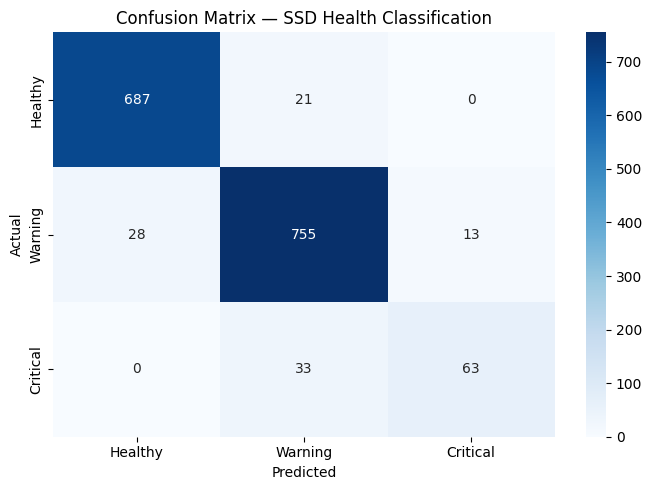

In [6]:
cm = confusion_matrix(yc_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SSD Health Classification")

plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
joblib.dump(clf, "../models/classifier.pkl")

print("Classifier saved.")

Classifier saved.


In [8]:
# Feature Importance Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

FEATURES = [
    "temperature",
    "wear_level",
    "power_on_hours",
    "write_cycles",
    "ECC_error_rate",
    "bad_blocks"
]

importances = clf.feature_importances_

feat_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
}).sort_values("importance", ascending=True)

print(
    feat_df.sort_values(
        "importance",
        ascending=False
    ).to_string(index=False)
)

       feature  importance
    wear_level    0.801199
    bad_blocks    0.047719
  write_cycles    0.040357
power_on_hours    0.038627
ECC_error_rate    0.036153
   temperature    0.035945


In [10]:
# Observation:
Wear level was the most influential feature (~80% importance),
followed by bad blocks. This aligns with the synthetic RUL
generation formula, where wear level has the largest impact
on SSD degradation.

SyntaxError: invalid syntax (2523348868.py, line 2)